<a href="https://colab.research.google.com/github/Amirhosseinpoor/FashionMnist/blob/main/FashionMnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install torch torchvision


In [10]:
import os
import math
import random
from collections import Counter, defaultdict

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
from PIL import Image


In [11]:
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

LABELS = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]


Device: cuda


In [12]:
root = "./data"
base_transform = transforms.ToTensor()
full_train_raw = datasets.FashionMNIST(root=root, train=True, download=True, transform=base_transform)
full_test_raw  = datasets.FashionMNIST(root=root, train=False, download=True, transform=base_transform)

all_images = torch.cat([full_train_raw.data, full_test_raw.data], dim=0)
all_targets = torch.cat([full_train_raw.targets, full_test_raw.targets], dim=0)

print("Total samples:", all_targets.shape[0])

def audit_counts(targets):
    cnt = Counter(targets.tolist())
    for k in sorted(cnt.keys()):
        print(f"Class {k:2d} ({LABELS[k]:12s}): {cnt[k]}")

audit_counts(all_targets)


100%|██████████| 26.4M/26.4M [00:01<00:00, 18.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 297kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.49MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 14.6MB/s]

Total samples: 70000
Class  0 (T-shirt/top ): 7000
Class  1 (Trouser     ): 7000
Class  2 (Pullover    ): 7000
Class  3 (Dress       ): 7000
Class  4 (Coat        ): 7000
Class  5 (Sandal      ): 7000
Class  6 (Shirt       ): 7000
Class  7 (Sneaker     ): 7000
Class  8 (Bag         ): 7000
Class  9 (Ankle boot  ): 7000


In [13]:
def stratified_split_indices(y, ratios=(0.8, 0.1, 0.1), seed=SEED):
    rng = random.Random(seed)
    buckets = defaultdict(list)
    for idx, c in enumerate(y.tolist()):
        buckets[c].append(idx)

    train_idx, val_idx, test_idx = [], [], []
    for c, idxs in buckets.items():
        rng.shuffle(idxs)
        n = len(idxs)
        n_train = int(round(ratios[0]*n))
        n_val   = int(round(ratios[1]*n))
        n_test  = n - n_train - n_val
        train_idx.extend(idxs[:n_train])
        val_idx.extend(idxs[n_train:n_train+n_val])
        test_idx.extend(idxs[n_train+n_val:])
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = stratified_split_indices(all_targets)

print("Train:", len(train_idx), "Val:", len(val_idx), "Test:", len(test_idx))


Train: 56000 Val: 7000 Test: 7000


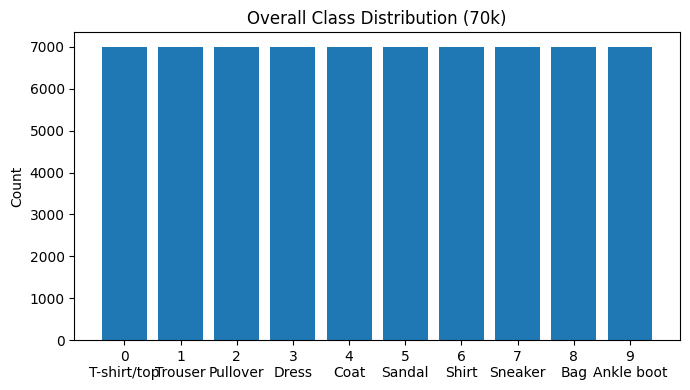

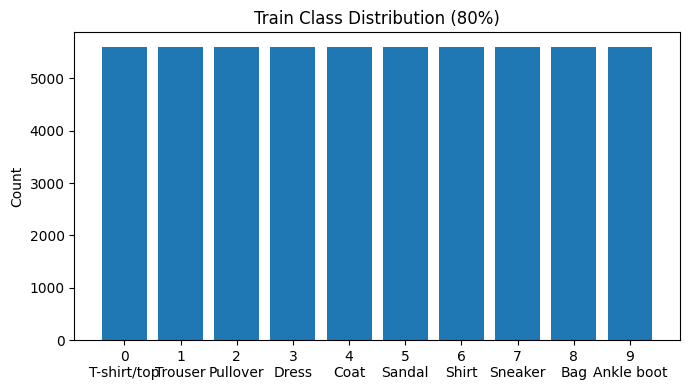

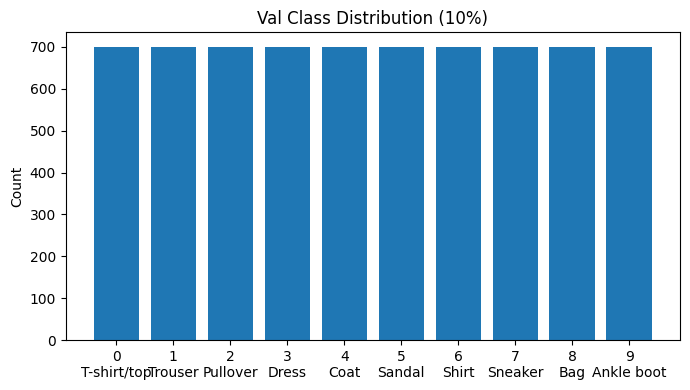

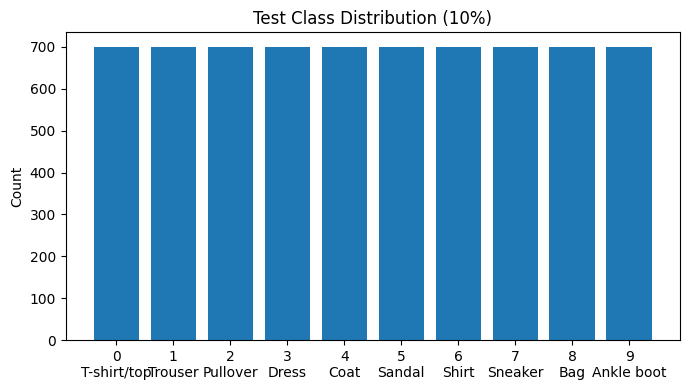

In [21]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

NUM_CLASSES = 10

def plot_class_dist(targets, title):
    cnt = Counter(targets.tolist())
    xs = np.arange(NUM_CLASSES)
    ys = [cnt.get(i, 0) for i in xs]
    plt.figure(figsize=(7,4))
    plt.bar(xs, ys)
    plt.xticks(xs, [f"{i}\n{LABELS[i]}" for i in xs])
    plt.title(title); plt.ylabel("Count"); plt.tight_layout(); plt.show()

plot_class_dist(all_targets, "Overall Class Distribution (70k)")
plot_class_dist(all_targets[train_idx], "Train Class Distribution (80%)")
plot_class_dist(all_targets[val_idx],   "Val Class Distribution (10%)")
plot_class_dist(all_targets[test_idx],  "Test Class Distribution (10%)")


In [14]:
with torch.no_grad():
    mean = (all_images[train_idx].float() / 255.0).mean().item()
    std  = (all_images[train_idx].float() / 255.0).std().item()

print("Mean:", mean, "Std:", std)

train_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=4),
    transforms.RandomHorizontalFlip(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])


Mean: 0.28608596324920654 Std: 0.3529439866542816


In [15]:
class ArrayDataset(Dataset):
    def __init__(self, images, targets, transform):
        self.images = images
        self.targets = targets
        self.transform = transform

    def __len__(self): return len(self.targets)

    def __getitem__(self, idx):
        img = Image.fromarray(self.images[idx].numpy(), mode="L")
        label = int(self.targets[idx])
        return self.transform(img), label

train_ds = ArrayDataset(all_images[train_idx], all_targets[train_idx], train_transform)
val_ds   = ArrayDataset(all_images[val_idx],   all_targets[val_idx],   eval_transform)
test_ds  = ArrayDataset(all_images[test_idx],  all_targets[test_idx],  eval_transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=512, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=512, shuffle=False, num_workers=2)


In [16]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(dropout),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout(dropout),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*7*7, 256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

class MLP(nn.Module):
    def __init__(self, hidden=(512,256), num_classes=10, dropout=0.2):
        super().__init__()
        layers, in_dim = [], 28*28
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers += [nn.Linear(in_dim, num_classes)]
        self.net = nn.Sequential(nn.Flatten(), *layers)
    def forward(self, x): return self.net(x)

# 🔹 Choose model here:
model_type = "cnn"  # or "mlp"
model = SmallCNN().to(device) if model_type=="cnn" else MLP().to(device)


In [17]:
EPOCHS = 20
criterion = nn.CrossEntropyLoss(label_smoothing=0.05 if model_type=="cnn" else 0.0)
optimizer = optim.AdamW(model.parameters(), lr=3e-3)
steps_per_epoch = math.ceil(len(train_loader))
scheduler = optim.lr_scheduler.OneCycleLR(optimizer, max_lr=3e-3,
                                          steps_per_epoch=steps_per_epoch,
                                          epochs=EPOCHS)


In [18]:
@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    cm = torch.zeros(10,10)
    for xb,yb in loader:
        xb,yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(1)
        correct += (preds==yb).sum().item()
        total += yb.size(0)
        for t,p in zip(yb.cpu(), preds.cpu()):
            cm[t.long(), p.long()] += 1
    acc = correct/total
    f1s = []
    for c in range(10):
        tp = cm[c,c].item()
        fp = cm[:,c].sum().item()-tp
        fn = cm[c,:].sum().item()-tp
        prec = tp/(tp+fp) if tp+fp>0 else 0
        rec  = tp/(tp+fn) if tp+fn>0 else 0
        f1   = 2*prec*rec/(prec+rec) if prec+rec>0 else 0
        f1s.append(f1)
    return acc, sum(f1s)/len(f1s)


In [19]:
best_val_f1 = 0.0
for epoch in range(1, EPOCHS+1):
    model.train()
    for xb,yb in train_loader:
        xb,yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 2.0)
        optimizer.step(); scheduler.step()
    val_acc,val_f1 = evaluate(model, val_loader)
    print(f"Epoch {epoch}/{EPOCHS} | ValAcc {val_acc*100:.2f}% | ValF1 {val_f1:.4f}")
    if val_f1>best_val_f1: best_val_f1=val_f1


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


Epoch 1/20 | ValAcc 77.94% | ValF1 0.7758


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


Epoch 2/20 | ValAcc 85.40% | ValF1 0.8499


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


...

Epoch 18/20 | ValAcc 94.11% | ValF1 0.9412


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


Epoch 19/20 | ValAcc 94.46% | ValF1 0.9444


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


Epoch 20/20 | ValAcc 94.44% | ValF1 0.9443


In [20]:
test_acc,test_f1 = evaluate(model, test_loader)
print("\n=== FINAL TEST METRICS ===")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Macro-F1: {test_f1:.4f}")


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")



=== FINAL TEST METRICS ===
Test Accuracy: 94.36%
Test Macro-F1: 0.9434


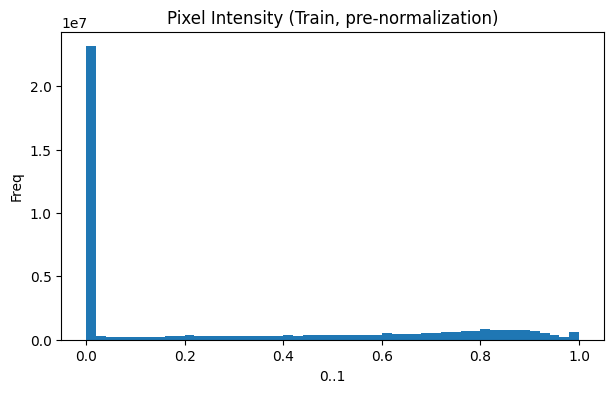

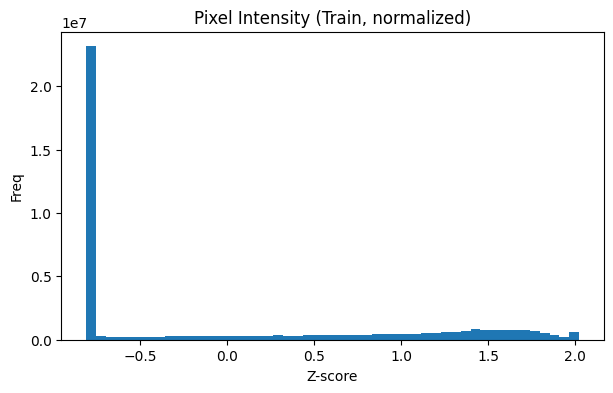

In [35]:
import torch, matplotlib.pyplot as plt

train_pixels = (all_images[train_idx].float() / 255.0)
plt.figure(figsize=(7,4))
plt.hist(train_pixels.flatten().numpy(), bins=50)
plt.title("Pixel Intensity (Train, pre-normalization)"); plt.xlabel("0..1"); plt.ylabel("Freq"); plt.show()

norm = ((train_pixels - mean) / std)
plt.figure(figsize=(7,4))
plt.hist(norm.flatten().numpy(), bins=50)
plt.title("Pixel Intensity (Train, normalized)"); plt.xlabel("Z-score"); plt.ylabel("Freq"); plt.show()


In [29]:
import numpy as np
import torch
import matplotlib.pyplot as plt

NUM_CLASSES = 10

@torch.no_grad()
def evaluate_with_cm(model, loader, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    correct, total = 0, 0
    cm = torch.zeros(NUM_CLASSES, NUM_CLASSES, dtype=torch.long)
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        preds = model(xb).argmax(1)
        correct += (preds == yb).sum().item()
        total += yb.size(0)
        for t, p in zip(yb.view(-1).cpu(), preds.view(-1).cpu()):
            cm[t.long(), p.long()] += 1
    acc = correct / total
    return acc, cm

def plot_confusion_matrix(cm, title):
    cm = cm.numpy().astype(np.int64)
    plt.figure(figsize=(6.2,5.6))
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title(title); plt.colorbar()
    ticks = np.arange(NUM_CLASSES)
    plt.xticks(ticks, ticks); plt.yticks(ticks, ticks)
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout(); plt.show()


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


Val Acc: 94.44%   |   Test Acc: 94.36%


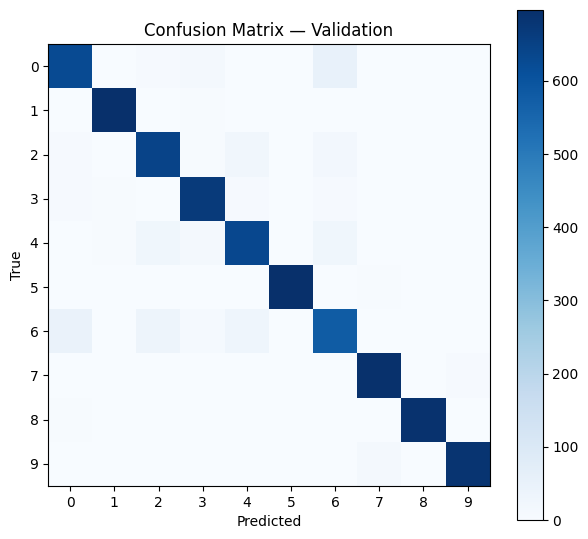

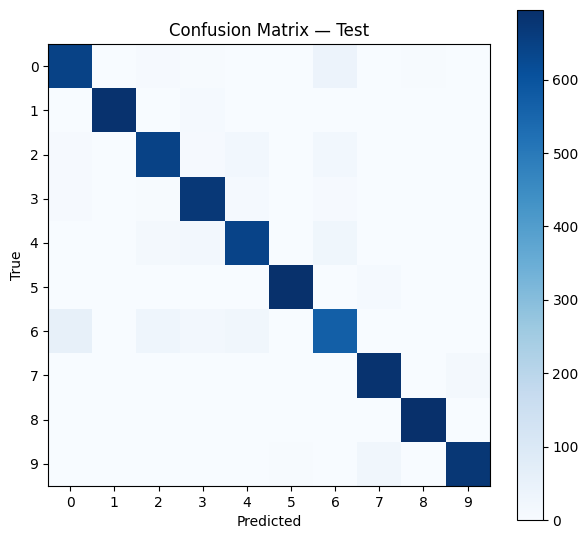

In [30]:
val_acc, cm_val  = evaluate_with_cm(model, val_loader)
test_acc, cm_test = evaluate_with_cm(model, test_loader)
print(f"Val Acc: {val_acc*100:.2f}%   |   Test Acc: {test_acc*100:.2f}%")
plot_confusion_matrix(cm_val,  "Confusion Matrix — Validation")
plot_confusion_matrix(cm_test, "Confusion Matrix — Test")


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


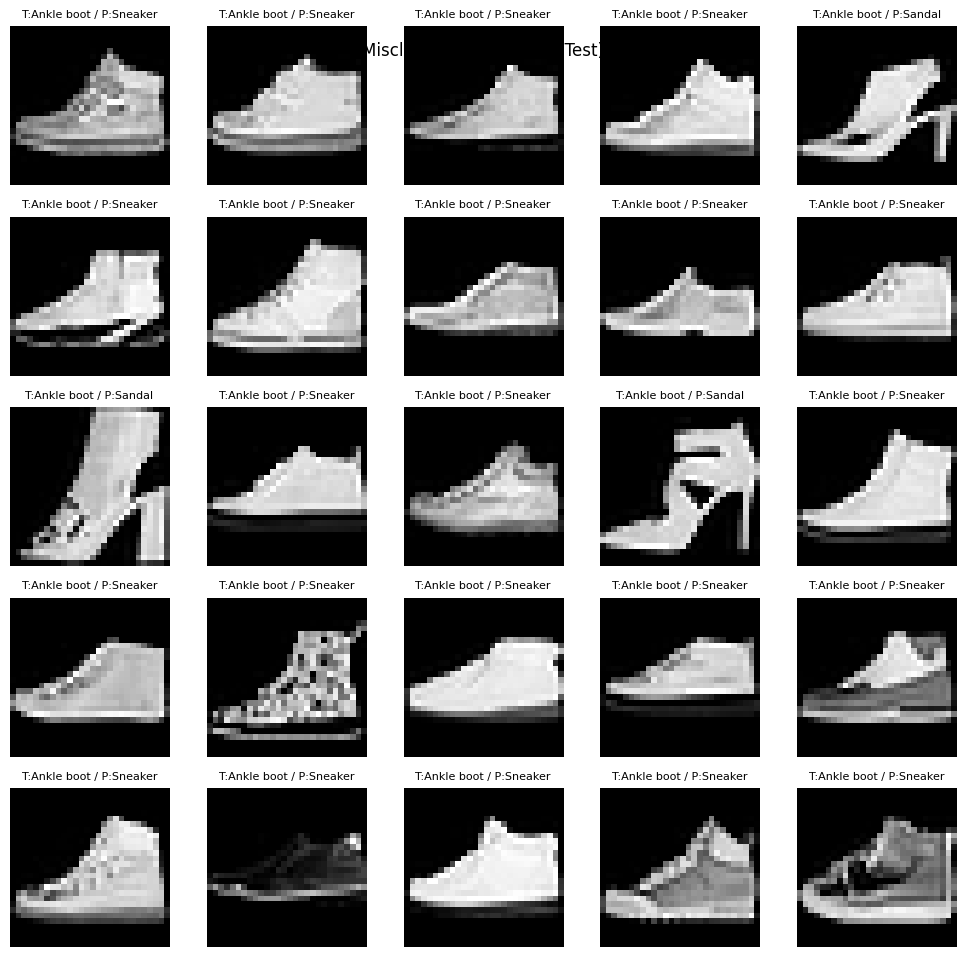

In [32]:
import torch, numpy as np, matplotlib.pyplot as plt

@torch.no_grad()
def collect_preds(model, loader, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    xs, ys, ps = [], [], []
    for xb, yb in loader:
        logits = model(xb.to(device))
        pred = logits.argmax(1).cpu()
        xs.append(xb.cpu()); ys.append(yb.cpu()); ps.append(pred.cpu())
    return torch.cat(xs,0), torch.cat(ys,0), torch.cat(ps,0)

xs, ys, ps = collect_preds(model, test_loader)
mis = torch.nonzero(ps != ys).flatten()
k = min(25, mis.numel())
sel = mis[:k]

if k > 0:
    rows = cols = int(np.ceil(k**0.5))
    fig, axes = plt.subplots(rows, cols, figsize=(10,10))
    for ax, i in zip(axes.flatten(), sel):
        # de-normalize for display:
        img = xs[i].squeeze().numpy()*std + mean
        ax.imshow(img, cmap="gray")
        ax.set_title(f"T:{LABELS[int(ys[i])]} / P:{LABELS[int(ps[i])]}", fontsize=8)
        ax.axis("off")
    plt.suptitle("Misclassified Examples (Test)", y=0.92)
    plt.tight_layout(); plt.show()
else:
    print("No misclassifications found.")


/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")
/tmp/ipython-input-1507437259.py:10: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = Image.fromarray(self.images[idx].numpy(), mode="L")


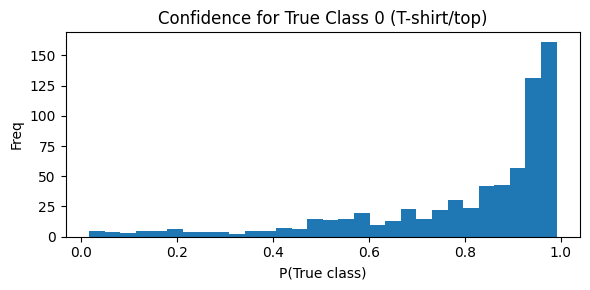

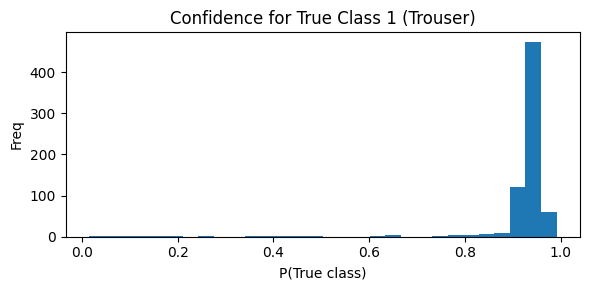

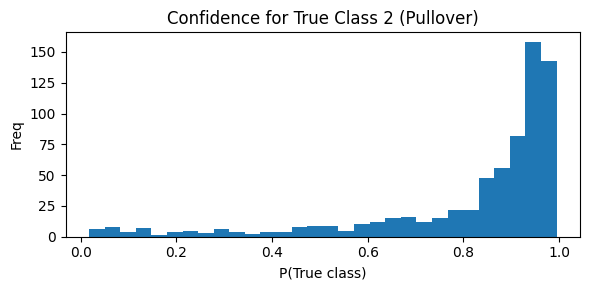

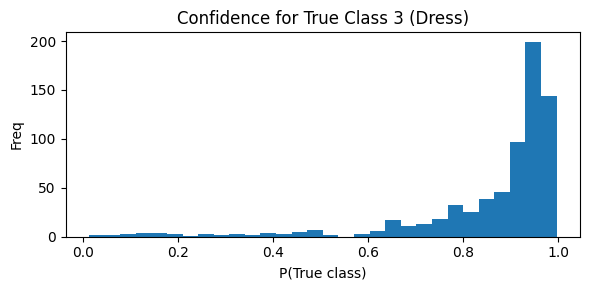

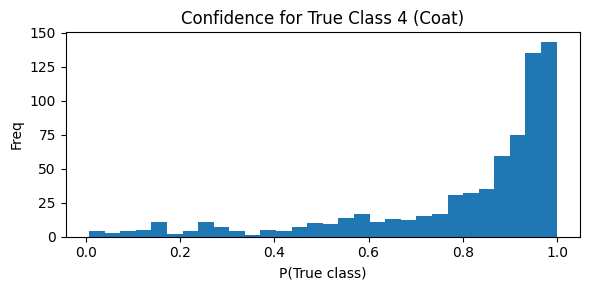

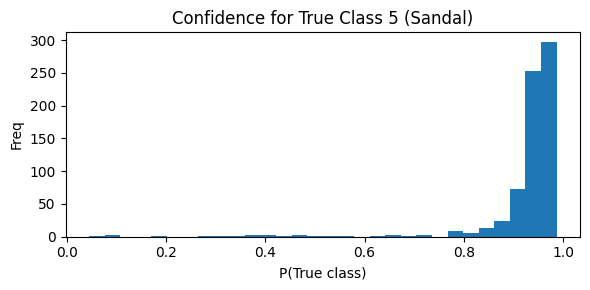

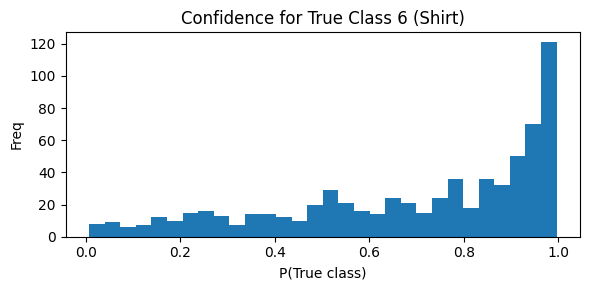

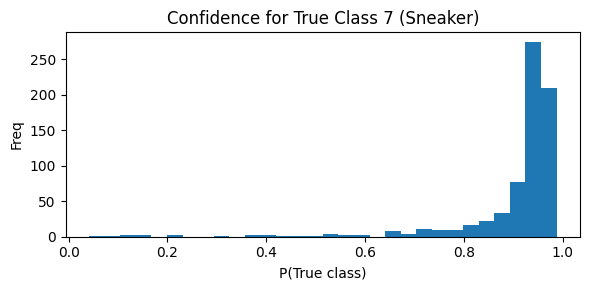

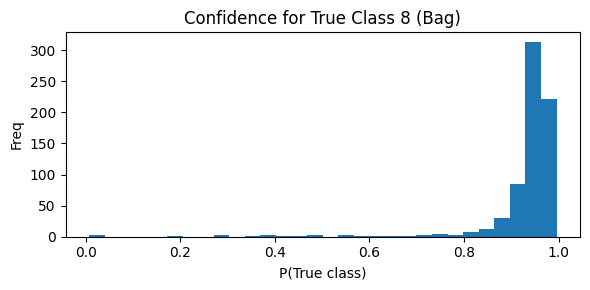

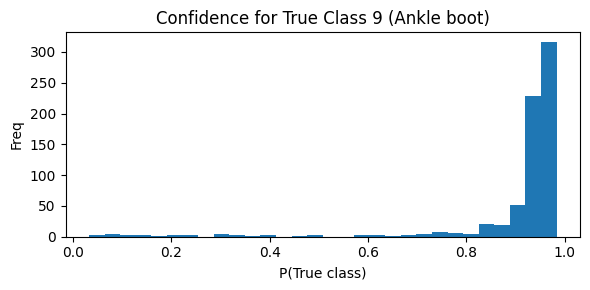

In [34]:
import torch, numpy as np, matplotlib.pyplot as plt

@torch.no_grad()
def probs_and_targets(model, loader, device=None):
    if device is None:
        device = next(model.parameters()).device
    model.eval()
    probs_all, tgts_all = [], []
    for xb, yb in loader:
        logits = model(xb.to(device))
        probs_all.append(logits.softmax(dim=1).cpu())
        tgts_all.append(yb.cpu())
    return torch.cat(probs_all,0), torch.cat(tgts_all,0)

probs, tgts = probs_and_targets(model, test_loader)
probs = probs.numpy(); tgts = tgts.numpy()

for c in range(NUM_CLASSES):
    idx = np.where(tgts == c)[0]
    if idx.size == 0: continue
    plt.figure(figsize=(6,3))
    plt.hist(probs[idx, c], bins=30)
    plt.title(f"Confidence for True Class {c} ({LABELS[c]})")
    plt.xlabel("P(True class)"); plt.ylabel("Freq"); plt.tight_layout(); plt.show()
